# Лабораторная работа №2
## Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных

**Цель лабораторной работы:** изучение способов предварительной обработки данных для дальнейшего формирования моделей.

В данной части лабораторной работы рассматривается набор данных **Auto MPG**.
Основное внимание уделяется обработке пропусков в числовых данных двумя способами:

1. **MICE (Iterative Imputation) на линейной регрессии**;
2. **CDF-импутация** на основе эмпирического распределения признака.

Также выполняется масштабирование числовых данных.

## Описание набора данных

Набор данных **Auto MPG** содержит характеристики автомобилей, влияющие на расход топлива.

В датасете представлены следующие признаки:
- `mpg` — расход топлива;
- `cylinders` — число цилиндров;
- `displacement` — рабочий объем двигателя;
- `horsepower` — мощность двигателя;
- `weight` — масса автомобиля;
- `acceleration` — ускорение;
- `model_year` — модельный год;
- `origin` — регион происхождения;
- `car_name` — название автомобиля.

Для данной лабораторной работы используются в основном числовые признаки.
Текстовый признак `car_name` исключается из анализа, так как в рамках этой части работы исследуется именно обработка числовых пропусков.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [14]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## Загрузка данных

In [16]:
columns_auto = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

df_auto_raw = pd.read_fwf(
    "../data/raw/auto-mpg.csv",
    header=None,
    names=columns_auto,
    na_values="?"
)

df_auto_raw.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,"""chevrolet chevelle malibu"""
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,"""buick skylark 320"""
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,"""plymouth satellite"""
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,"""amc rebel sst"""
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,"""ford torino"""


## Первичный просмотр набора данных

In [17]:
df_auto_raw.shape

(398, 9)

In [18]:
df_auto_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [19]:
df_auto_raw.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

По результатам первичного анализа видно, что в наборе данных присутствуют пропущенные значения.
Основное внимание будет уделено их обработке в числовых признаках.

## Подготовка данных

Для числового анализа удалим текстовый столбец `car_name` и оставим только количественные признаки.

In [20]:
df_auto = df_auto_raw.drop(columns=["car_name"]).copy()

for col in df_auto.columns:
    df_auto[col] = pd.to_numeric(df_auto[col], errors="coerce")

df_auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [21]:
df_auto.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
dtype: object

In [23]:
df_auto.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


## Визуализация пропусков

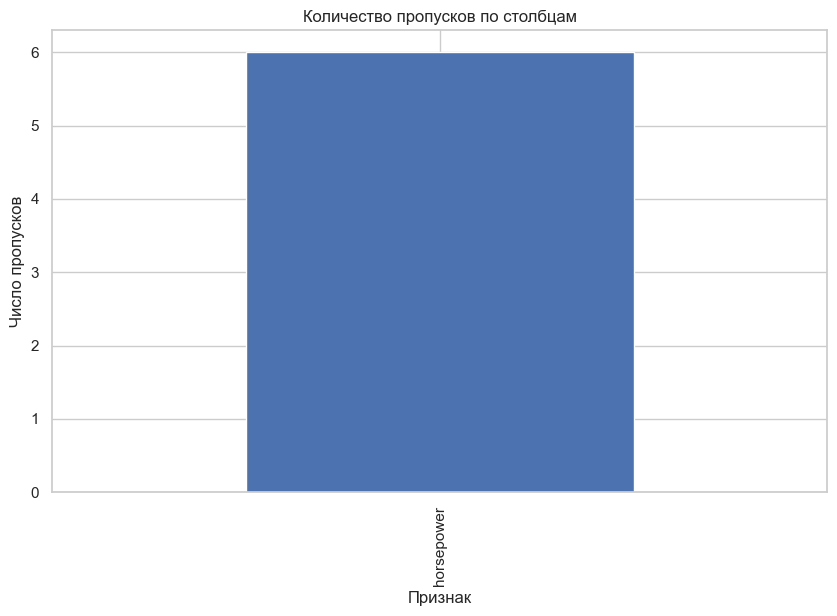

In [26]:
missing_counts = df_auto.isna().sum().sort_values(ascending=False)
missing_counts
missing_counts[missing_counts > 0].plot(kind="bar")
plt.title("Количество пропусков по столбцам")
plt.xlabel("Признак")
plt.ylabel("Число пропусков")
plt.show()

## Подготовка функции CDF-импутации

CDF-импутация основана на эмпирическом распределении наблюдаемых значений признака.
Суть метода состоит в том, что пропущенные значения заменяются не средним или медианой, а значениями, случайно сгенерированными из распределения, близкого к реальному распределению наблюдаемых данных.

Это позволяет лучше сохранять форму распределения признака.

In [27]:
def cdf_impute_series(series, random_state=42):
    rng = np.random.default_rng(random_state)
    s = series.copy()
    missing_mask = s.isna()

    observed = s.dropna().to_numpy()

    if len(observed) == 0:
        return s

    observed_sorted = np.sort(observed)
    u = rng.uniform(0, 1, size=missing_mask.sum())

    quantiles = np.quantile(observed_sorted, u)
    s.loc[missing_mask] = quantiles

    return s

In [28]:
df_auto_cdf = df_auto.copy()

for col in df_auto_cdf.columns:
    if df_auto_cdf[col].isna().sum() > 0:
        df_auto_cdf[col] = cdf_impute_series(df_auto_cdf[col], random_state=42)

df_auto_cdf.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

## Заполнение пропусков методом MICE на линейной регрессии

Для второй схемы обработки пропусков используется **IterativeImputer** с моделью **LinearRegression**.
В данном случае каждый признак с пропусками по очереди предсказывается на основе остальных признаков.

В отличие от CDF-импутации, данный подход учитывает взаимосвязи между признаками.

In [29]:
lin_reg = LinearRegression()

mice_imputer = IterativeImputer(
    estimator=lin_reg,
    max_iter=20,
    random_state=42,
    initial_strategy="median"
)

df_auto_mice = pd.DataFrame(
    mice_imputer.fit_transform(df_auto),
    columns=df_auto.columns
)

df_auto_mice.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

## Сравнение распределений после импутации

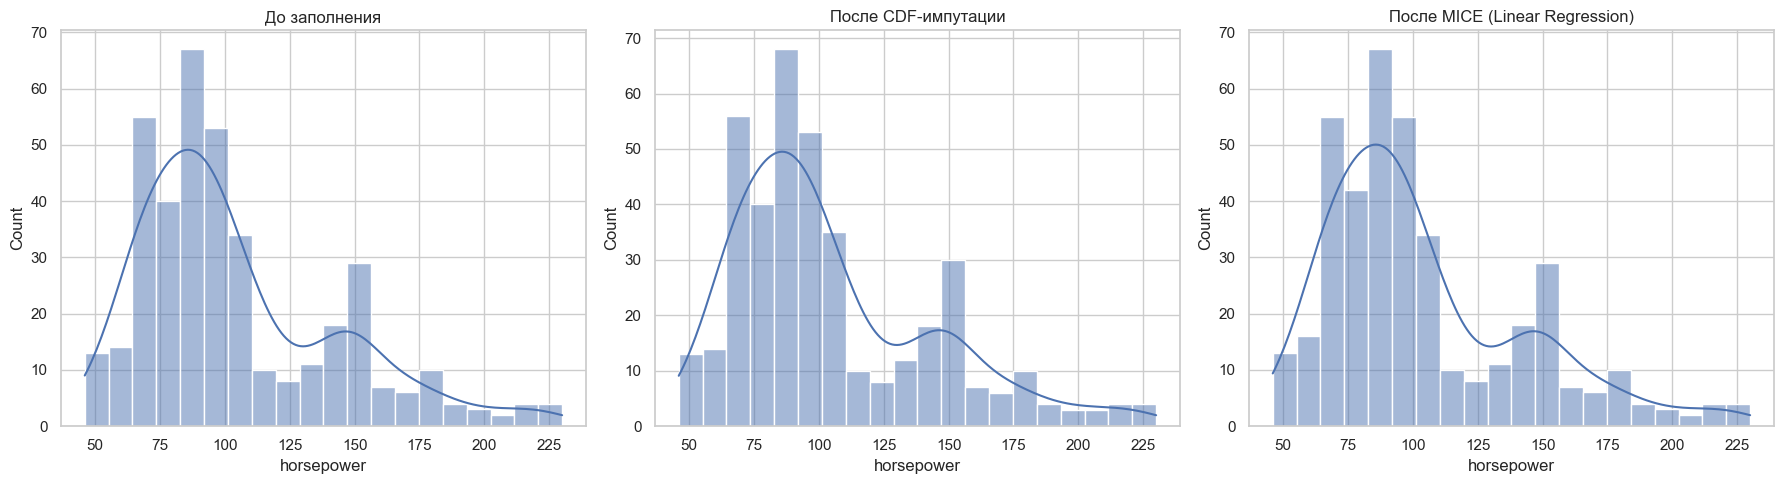

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_auto["horsepower"], kde=True, bins=20, ax=axes[0])
axes[0].set_title("До заполнения")

sns.histplot(df_auto_cdf["horsepower"], kde=True, bins=20, ax=axes[1])
axes[1].set_title("После CDF-импутации")

sns.histplot(df_auto_mice["horsepower"], kde=True, bins=20, ax=axes[2])
axes[2].set_title("После MICE (Linear Regression)")

plt.tight_layout()
plt.show()

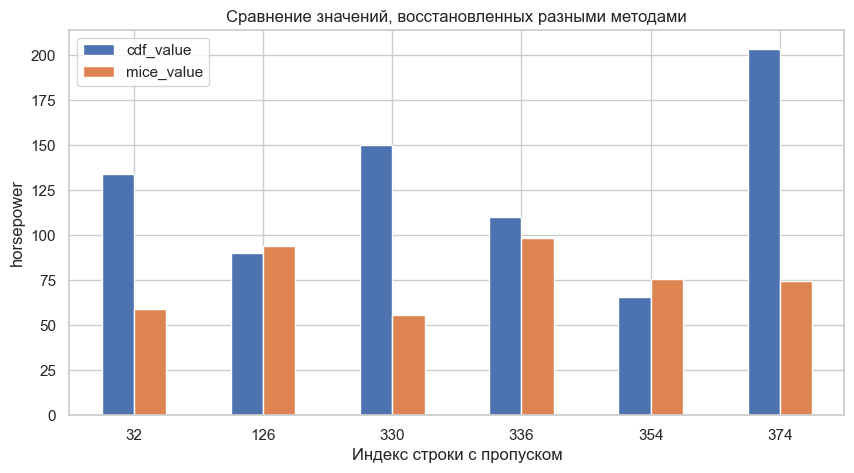

In [38]:
missing_idx = df_auto[df_auto["horsepower"].isna()].index
missing_idx
comparison_imputed_values = pd.DataFrame({
    "cdf_value": df_auto_cdf.loc[missing_idx, "horsepower"],
    "mice_value": df_auto_mice.loc[missing_idx, "horsepower"]
})

comparison_imputed_values
comparison_imputed_values.plot(kind="bar", figsize=(10, 5))
plt.title("Сравнение значений, восстановленных разными методами")
plt.xlabel("Индекс строки с пропуском")
plt.ylabel("horsepower")
plt.xticks(rotation=0)
plt.show()

## Масштабирование данных

In [31]:
df_auto_final = df_auto_mice.copy()
df_auto_final.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0


In [35]:
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

df_auto_standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(df_auto_final),
    columns=df_auto_final.columns
)

df_auto_minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(df_auto_final),
    columns=df_auto_final.columns
)

In [36]:
df_auto_standard_scaled.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,-0.706439,1.498191,1.090604,0.676709,0.630870,-1.295498,-1.627426,-0.715145
1,-1.090751,1.498191,1.503514,1.589232,0.854333,-1.477038,-1.627426,-0.715145
2,-0.706439,1.498191,1.196232,1.198151,0.550470,-1.658577,-1.627426,-0.715145
3,-0.962647,1.498191,1.061796,1.198151,0.546923,-1.295498,-1.627426,-0.715145
4,-0.834543,1.498191,1.042591,0.937430,0.565841,-1.840117,-1.627426,-0.715145


In [37]:
df_auto_minmax_scaled.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,0.239362,1.0,0.617571,0.456522,0.536150,0.238095,0.0,0.0
1,0.159574,1.0,0.728682,0.646739,0.589736,0.208333,0.0,0.0
2,0.239362,1.0,0.645995,0.565217,0.516870,0.178571,0.0,0.0
3,0.186170,1.0,0.609819,0.565217,0.516019,0.238095,0.0,0.0
4,0.212766,1.0,0.604651,0.510870,0.520556,0.148810,0.0,0.0


## Выводы

В данной части лабораторной работы был исследован набор данных **Auto MPG** с пропусками в числовых признаках.

В ходе работы были выполнены следующие действия:
- загружен и проанализирован набор данных;
- выделены числовые признаки;
- обнаружены пропуски в признаке `horsepower`;
- реализованы два способа заполнения пропусков:
  - **CDF-импутация**;
  - **MICE (Iterative Imputation) на линейной регрессии**;
- проведено сравнение результатов восстановления пропусков;
- выполнено масштабирование данных с помощью **StandardScaler** и **MinMaxScaler**.

Анализ показал, что при небольшом количестве пропусков общая форма распределения признака `horsepower` после импутации изменяется незначительно. Однако при сравнении значений, восстановленных в конкретных строках, различия между методами становятся заметными.

По результатам сравнения можно сделать следующие выводы:
- **CDF-импутация** в ряде случаев восстанавливала более высокие значения `horsepower`;
- значения, полученные методом CDF, имеют больший разброс;
- **MICE на линейной регрессии** давал более умеренные и сглаженные оценки;
- MICE восстанавливает пропуски на основе взаимосвязей между признаками, тогда как CDF ориентируется в первую очередь на распределение самого признака.

Таким образом, методы решают разные задачи:
- **CDF-импутация** лучше сохраняет общую форму распределения отдельного признака;
- **MICE** лучше учитывает многомерную структуру данных и связи между признаками.

Следовательно, выбор метода заполнения пропусков зависит от цели анализа:
- если важно сохранить распределение признака, предпочтительнее CDF;
- если важно учитывать зависимость между признаками, предпочтительнее MICE.